# PRODUCTION

## Matching metadata with the departments of DTU and plotting distributions

The data cleaning/matching result have been uploaded to GCP bucket under file name: `thesis_meta_combined_department.csv`

In [1]:
import json
import pandas as pd
import re


### Imporing the JSON file with the departments and sections of DTU
with open('../Data/Departments_DTU_all.json', 'r') as f:
    dep = json.load(f)
    print(f"Loaded {len(dep)} departments from JSON file.")

### Importing the csv file with all metadata
csv_path = "../Data/Exploring_meta/thesis_meta_combined_filtered.csv"
df_csv = pd.read_csv(csv_path, sep=";", encoding="utf-8")

print("Loaded the metadata with a shape of: ", df_csv.shape)
#display(df_csv.head())

### Lookup from JSON (dep) and map Publisher -> Department_new in df_csv
def _flatten_text(value):
    """Return a flat list of strings from nested str/list/dict structures."""
    out = []
    if value is None:
        return out
    if isinstance(value, str):
        out.extend([v.strip() for v in value.split("|") if v.strip()])
    elif isinstance(value, list):
        for v in value:
            out.extend(_flatten_text(v))
    elif isinstance(value, dict):
        for v in value.values():
            out.extend(_flatten_text(v))
    return out

def _norm(s):
    s = str(s).strip().lower()
    s = re.sub(r"^dtu\s+", "", s)         # remove leading "DTU "
    s = re.sub(r"\s+", " ", s)            # normalize spaces
    return s

def _department_value(dep_item):
    d = dep_item.get("department")
    if isinstance(d, dict):
        return d.get("en") or d.get("da") or next((str(v) for v in d.values() if v), None)
    return d

# 1) Create alias -> department lookup from title + sections
alias_to_department = {}

for item in dep:
    department_val = _department_value(item)

    aliases = []
    aliases.extend(_flatten_text(item.get("title")))
    aliases.extend(_flatten_text(item.get("sections")))

    for a in aliases:
        alias_to_department[_norm(a)] = department_val

# 2) Map each Publisher to department
def map_publisher_to_department(publisher):
    if pd.isna(publisher):
        return pd.NA
    
    p_norm = _norm(publisher)

    # exact match first
    if p_norm in alias_to_department:
        return alias_to_department[p_norm]

    # fallback: contains match either direction
    for alias, dep_val in alias_to_department.items():
        if alias in p_norm or p_norm in alias:
            return dep_val

    return pd.NA

df_csv["Department_new"] = df_csv["Publisher"].apply(map_publisher_to_department)

print("Matched rows:", df_csv["Department_new"].notna().sum(), "/", len(df_csv))
display(df_csv[["Publisher", "Department_new"]].head(20))

# Add new CSV or overwrite CSV with new column
csv_path_export = "../Data/Exploring_meta/thesis_meta_combined_department.csv"
df_csv.to_csv(csv_path_export, sep=";", encoding="utf-8", index=False)
print(f"Saved updated file: {csv_path_export}")

### Test for unmatched rows:
if df_csv["Department_new"].notna().sum() - len(df_csv) != 0:
    # Follow-up: show unmatched publishers (where Department_new is missing)
    print("Not all rows were matched, the unmatched rows are:")
    print()
    if "df_csv" not in globals():
        raise NameError("df_csv is not defined. Run the CSV loading cell first.")
    if "Department_new" not in df_csv.columns:
        raise KeyError("Department_new column not found. Run the mapping cell first.")

    unmatched_publishers = (
        df_csv.loc[df_csv["Department_new"].isna(), "Publisher"]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
        .value_counts()
        .rename_axis("Publisher")
        .reset_index(name="Count")
    )

    print(f"Unmatched rows: {unmatched_publishers['Count'].sum()} / {len(df_csv)}")
    display(unmatched_publishers.head(30))

Loaded 17 departments from JSON file.
Loaded the metadata with a shape of:  (6254, 16)
Matched rows: 6254 / 6254


,Publisher,Department_new
0,DTU DTU National Food Institute,DTU Food
1,DTU Department of Civil and Mechanical Enginee...,DTU Construct
2,DTU Department of Applied Mathematics and Comp...,DTU Compute
3,DTU Department of Environmental and Resource E...,DTU Sustain
4,DTU Department of Health Technology,DTU Health Tech
5,DTU Department of Health Technology,DTU Health Tech
6,DTU Department of Applied Mathematics and Comp...,DTU Compute
7,DTU Department of Applied Mathematics and Comp...,DTU Compute
8,DTU Department of Electrical and Photonics Eng...,DTU Electro
9,DTU Department of Applied Mathematics and Comp...,DTU Compute


Saved updated file: ../Data/Exploring_meta/thesis_meta_combined_department.csv


### Distribution of (for PDFs avialable) MSc Thesis per DTU Department - *the smale set*

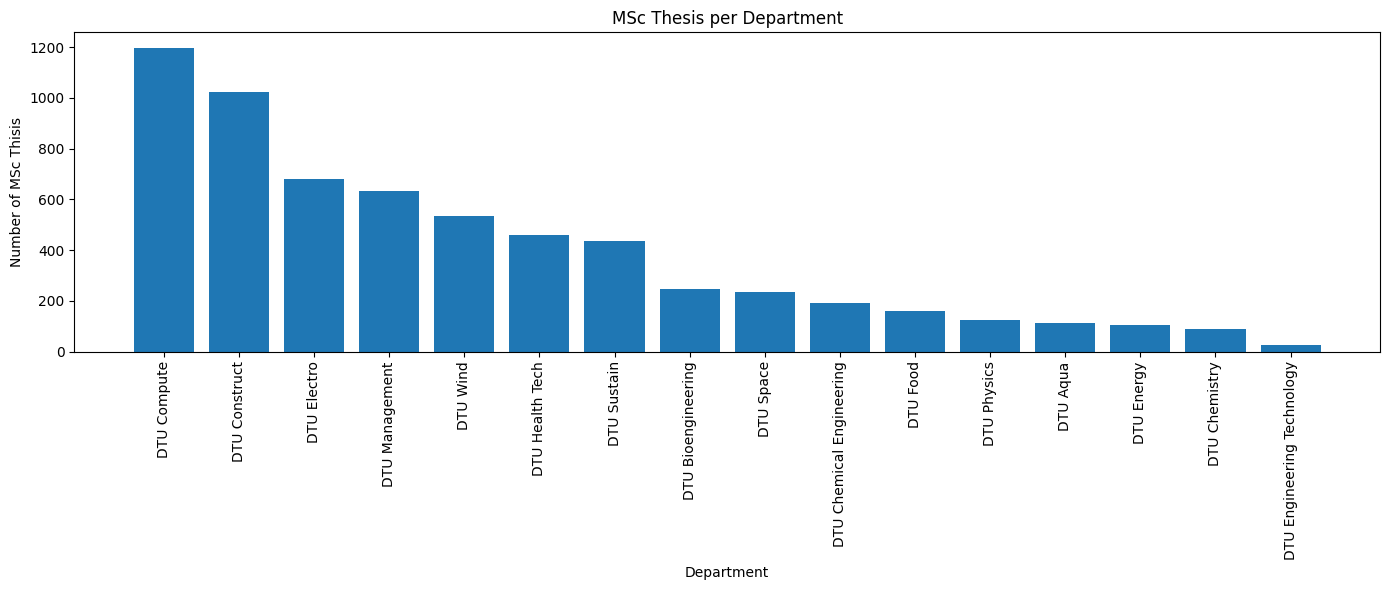

In [2]:
import os
import matplotlib.pyplot as plt

publisher_counts = df_csv["Department_new"].fillna("Missing").value_counts()

plt.figure(figsize=(14, 6))
plt.bar(publisher_counts.index.astype(str), publisher_counts.values)
plt.xlabel("Department")
plt.ylabel("Number of MSc Thisis")
plt.title("MSc Thesis per Department")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# DEVELOPMENT

### Distribution of (all time) MSc Thesis per DTU Department - *the large set*

In [3]:
from pathlib import Path
import pandas as pd
import re

pd.set_option("display.max_colwidth", None)  # Show full text in cells

def read_parquet(path_to_file):
    # Set your parquet file path here (works from project root or pdf_reader/)
    parquet_rel = Path(path_to_file)
    parquet_path = parquet_rel if parquet_rel.exists() else Path("..") / parquet_rel
    parquet_path = parquet_path.resolve()

    # Read parquet into a DataFrame ("unpack")
    df = pd.read_parquet(parquet_path)
    #df = df.drop_duplicates()  # Remove duplicates if needed

    # Quick check
    print(f"Using: {parquet_path}")
    print("Unpackaging compleet.")
    print(f"DataFrame shape: {df.shape}")

    return df

def affiliations_cleaning(df):
    pattern = re.compile(
        r"(Department of [^|]*?, Technical University of Denmark|"
        r"Institut for [^|]*?, Danmarks Tekniske Universitet)"
    )

    def clean_affiliations_cell(value):
        if pd.isna(value):
            return value  # or "" if you prefer empty string

        text = (
            str(value)
            .replace("[affiliation name could not be established]|", "")
            .replace("|[affiliation unknown]", "")
            .strip("|")
        )

        matches = pattern.findall(text)

        cleaned = [
            m.replace(", Technical University of Denmark", "")
            .replace(", Danmarks Tekniske Universitet", "")
            .strip()
            for m in matches
        ]

        cleaned = list(dict.fromkeys([c for c in cleaned if c]))  # dedupe, keep order
        return "|".join(cleaned)

    # 1) Keep original
    df["Affiliations_raw"] = df["Affiliations"]

    # 2) Create cleaned version
    df["Affiliations_clean"] = df["Affiliations_raw"].apply(clean_affiliations_cell)

    # Optional: if you eventually want cleaned to become main column
    # df["Affiliations"] = df["Affiliations_clean"]
    return df

df_raw = read_parquet("Data/Exploring_meta/thesis_meta_combined.parquet")
#display(df_raw.head(3))

df_aff = affiliations_cleaning(df_raw)
display(df_aff[["Affiliations_raw", "Affiliations_clean"]].head())

aff_count = len(df_aff["Affiliations_clean"].dropna().unique())
print(f"Unique cleaned affiliations: {aff_count}")

Using: /Users/oliver/Desktop/MSc_Speciale/Thesis_OCR/Data/Exploring_meta/thesis_meta_combined.parquet
Unpackaging compleet.
DataFrame shape: (19690, 40)


,Affiliations_raw,Affiliations_clean
0,"Depatment of Systems Biology, Technical University of Denmark|Novozymes A/S|Department of Systems Biology, Technical University of Denmark",Department of Systems Biology
1,"[affiliation name could not be established]|Automation, Ørsted DTU, Technical University of Denmark|[affiliation unknown]",
2,"[affiliation name could not be established]|Institut for Planlægning, Innovation og Ledelse, Danmarks Tekniske Universitet|[affiliation unknown]","Institut for Planlægning, Innovation og Ledelse"
3,"Ørsted•DTU, Technical University of Denmark",
4,"Intelligent Signal Processing, Informatics and Mathematical Modelling, Technical University of Denmark",


Unique cleaned affiliations: 68


In [4]:
import json
import pandas as pd
import re

pd.set_option("display.max_colwidth", None)  # Show full text in cells

### Imporing the JSON file with the departments and sections of DTU
with open('../Data/Departments_DTU_all.json', 'r') as f:
    dep = json.load(f)
    print(f"Loaded {len(dep)} departments from JSON file.")

### Lookup from JSON (dep) and map Publisher -> Department_new in df_aff
def _flatten_text(value):
    """Return a flat list of strings from nested str/list/dict structures."""
    out = []
    if value is None:
        return out
    if isinstance(value, str):
        out.extend([v.strip() for v in value.split("|") if v.strip()])
    elif isinstance(value, list):
        for v in value:
            out.extend(_flatten_text(v))
    elif isinstance(value, dict):
        for v in value.values():
            out.extend(_flatten_text(v))
    return out

def _norm(s):
    s = str(s).strip().lower()
    s = re.sub(r"^dtu\s+", "", s)         # remove leading "DTU "
    s = re.sub(r"\s+", " ", s)            # normalize spaces
    return s

def _department_value(dep_item):
    d = dep_item.get("department")
    if isinstance(d, dict):
        return d.get("en") or d.get("da") or next((str(v) for v in d.values() if v), None)
    return d

# 1) Create alias -> department lookup from title + sections
alias_to_department = {}

for item in dep:
    department_val = _department_value(item)

    aliases = []
    aliases.extend(_flatten_text(item.get("title")))
    aliases.extend(_flatten_text(item.get("sections")))

    for a in aliases:
        alias_to_department[_norm(a)] = department_val

# 2) Base mapper used by both Publisher and Affiliations_clean
def map_text_to_department(text_value):
    if pd.isna(text_value):
        return pd.NA

    value_norm = _norm(text_value)

    # exact match first
    if value_norm in alias_to_department:
        return alias_to_department[value_norm]

    # fallback: contains match either direction
    for alias, dep_val in alias_to_department.items():
        if alias in value_norm or value_norm in alias:
            return dep_val

    return pd.NA

def map_affiliations_to_department(affiliations_value):
    """Try each cleaned affiliation token (split by '|') until one department matches."""
    if pd.isna(affiliations_value):
        return pd.NA

    for token in [t.strip() for t in str(affiliations_value).split("|") if t.strip()]:
        dep_val = map_text_to_department(token)
        if pd.notna(dep_val):
            return dep_val

    return pd.NA

# First pass: match with Publisher exactly as before
df_aff["Department_new"] = df_aff["Publisher"].apply(map_text_to_department)
publisher_matched = df_aff["Department_new"].notna().sum()

# Second pass: only unmatched rows, try Affiliations_clean
unmatched_mask = df_aff["Department_new"].isna()
affiliations_matched = 0
if unmatched_mask.any() and "Affiliations_clean" in df_aff.columns:
    second_pass = df_aff.loc[unmatched_mask, "Affiliations_clean"].apply(map_affiliations_to_department)
    affiliations_matched = second_pass.notna().sum()
    df_aff.loc[unmatched_mask, "Department_new"] = second_pass

total_matched = df_aff["Department_new"].notna().sum()
print(f"Matched from Publisher: {publisher_matched}")
print(f"Additional matched from Affiliations_clean: {affiliations_matched}")
print(f"Total matched rows: {total_matched} / {len(df_aff)}")
display(df_aff[["Publisher", "Affiliations_clean", "Department_new"]].head(20))

# Add new CSV or overwrite CSV with new column
overwrite_case = input("Do you want to overwrite the existing CSV with the new Department column? (yes/no): ").strip().lower()
if overwrite_case == "yes":
    csv_path_export = "../Data/Exploring_meta/thesis_meta_combined_department.csv"
    df_aff.to_csv(csv_path_export, sep=";", encoding="utf-8", index=False)
    print(f"Saved updated file: {csv_path_export}")

### Test for unmatched rows
if df_aff["Department_new"].isna().any():
    # Follow-up: show unmatched publishers (where Department_new is still missing)
    print("Not all rows were matched, the unmatched rows are:")
    print()
    if "df_aff" not in globals():
        raise NameError("df_aff is not defined. Run the DataFrame loading cell first.")
    if "Department_new" not in df_aff.columns:
        raise KeyError("Department_new column not found. Run the mapping cell first.")

    unmatched_publishers = (
        df_aff.loc[df_aff["Department_new"].isna(), "Publisher"]
        .fillna("Missing")
        .astype(str)
        .str.strip()
        .replace("", "Missing")
        .value_counts()
        .rename_axis("Publisher")
        .reset_index(name="Count")
    )

    print(f"Unmatched rows: {unmatched_publishers['Count'].sum()} / {len(df_aff)}")
    display(unmatched_publishers)
else:
    print("All rows matched after Publisher + Affiliations_clean passes.")

Loaded 17 departments from JSON file.
Matched from Publisher: 16414
Additional matched from Affiliations_clean: 341
Total matched rows: 16755 / 19690


,Publisher,Affiliations_clean,Department_new
0,None,Department of Systems Biology,<NA>
1,None,,<NA>
2,None,"Institut for Planlægning, Innovation og Ledelse",<NA>
3,None,,<NA>
4,None,,<NA>
5,None,Department of Transport,<NA>
6,"Department of Informatics and Mathematical Modeling, Technical University of Denmark, DTU",Department of Informatics and Mathematical Modeling,<NA>
7,"Danmarks Tekniske Universitet, Risø Nationallaboratoriet for Bæredygtig Energi",,<NA>
8,Technical University of Denmark (DTU),Department of Informatics and Mathematical Modeling,<NA>
9,None,Department of Chemical Engineering,<NA>


Not all rows were matched, the unmatched rows are:

Unmatched rows: 2935 / 19690


,Publisher,Count
0,Missing,1408
1,Technical University of Denmark (DTU),405
2,"Department of Informatics and Mathematical Modeling, Technical University of Denmark, DTU",391
3,DTU Department of Informatics and Mathematical Modeling,201
4,DTU National Veterinary Institute,106
5,DTU Department of Transport,79
6,"Institut for Informatik og Matematisk Modellering, Danmarks Tekniske Universitet, DTU",75
7,IPL,71
8,"Institut for Produktion og Ledelse, DTU",51
9,DTU Risø National Laboratory for Sustainable Energy,36


#### PLOT Distribution of the unmatched

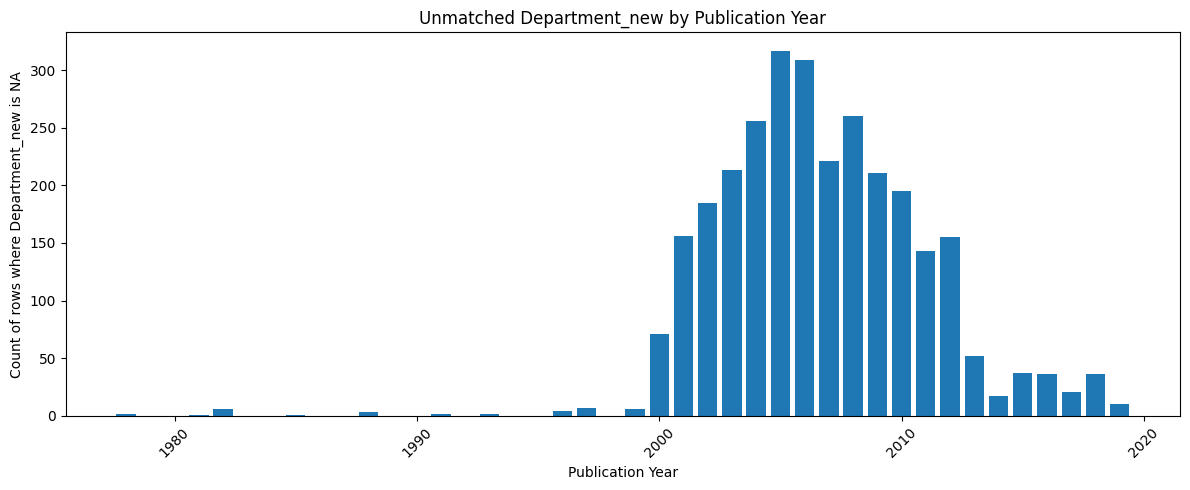

Min Publication Year: 1978
Max Publication Year: 2019


In [5]:
import os
import matplotlib.pyplot as plt

subset_unmatched = df_aff.loc[
    df_aff["Department_new"].isna(),
    ["Publisher", "Affiliations_clean", "Department_new", "Publication Year"]
]

year_counts = (
    subset_unmatched.groupby("Publication Year")
    .size()
    .sort_index()
)

#print(year_counts)

plt.figure(figsize=(12, 5))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Publication Year")
plt.ylabel('Count of rows where Department_new is NA')
plt.title('Unmatched Department_new by Publication Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Min Publication Year:", subset_unmatched["Publication Year"].min())
print("Max Publication Year:", subset_unmatched["Publication Year"].max())


#### PLOT Distribution of (all time) MSc Thesis per DTU Department

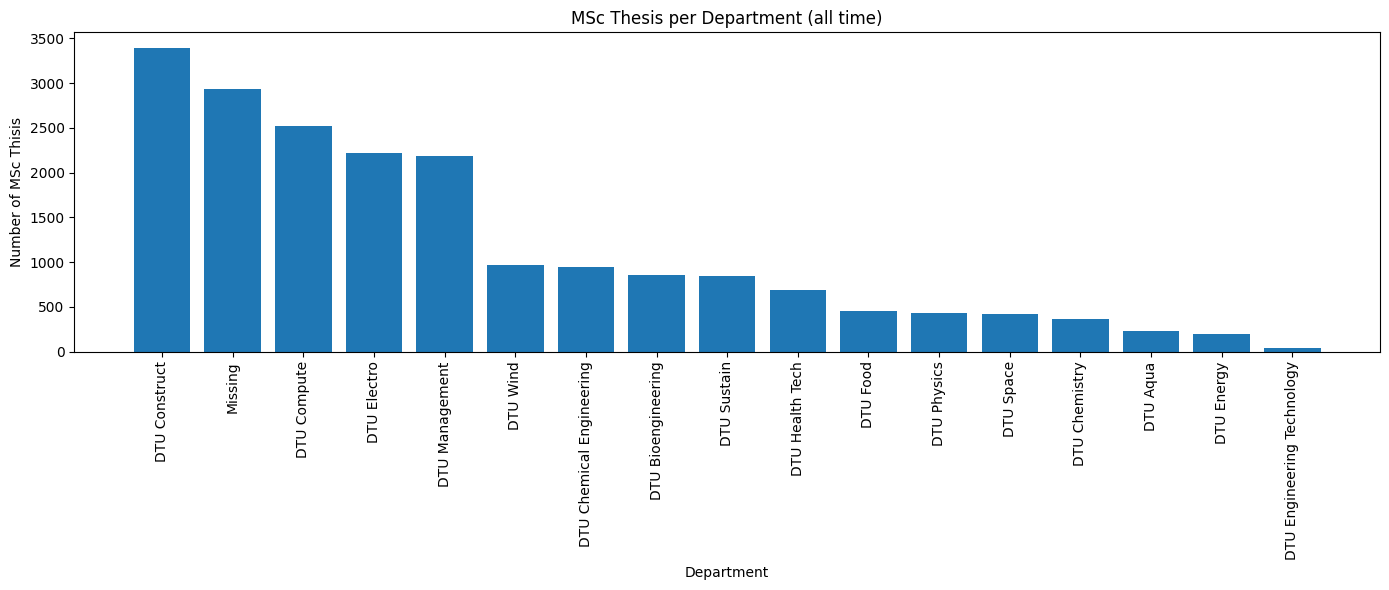

In [6]:
import os
import matplotlib.pyplot as plt

publisher_counts = df_aff["Department_new"].fillna("Missing").value_counts()

plt.figure(figsize=(14, 6))
plt.bar(publisher_counts.index.astype(str), publisher_counts.values)
plt.xlabel("Department")
plt.ylabel("Number of MSc Thisis")
plt.title("MSc Thesis per Department (all time)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()